# Red neuronal artificial para reconocer el tipo de un pokemon

En esta tarea ustedes deben diseñar, entrenar y evaluar un modelo de red neuronal con arquitectura convolucional para resolver el problema de reconocer el tipo de un pokemon en base a una imagen del mismo y a sus atributos. El principal desafio es el desbalance y poca cantidad de ejemplos en el dataset. 

A continuación se instancia el dataset y se itera para presentar algunos ejemplos:

In [ ]:
%load_ext autoreload
%autoreload 2
%matplotlib inline
import matplotlib.pyplot as plt
from pokemon_utils import PokemonImages

dataset = PokemonImages('data/')

fig, ax = plt.subplots(3, 3, figsize=(7, 5), tight_layout=True)
for ax_, (image, label, name, attributes) in zip(ax.ravel(), dataset):
    ax_.imshow(image.permute(-2, -1, 0))
    ax_.axis('off');

Cada ejemplo tiene su imagen, su etiqueta, su nombre y sus atributos:

In [ ]:
image, label, name, attributes = dataset[0]
type(image), image.shape, label, name, attributes

(torch.Tensor,
 torch.Size([3, 256, 256]),
 np.int64(9),
 'Bulbasaur',
 tensor([ 0.7000,  6.9000, 45.0000, 49.0000, 49.0000, 45.0000]))

Se puede obtener el nombre de la clase con:

In [ ]:
dataset.categories[label]

'Grass'

Y los atributos disponibles son:

In [ ]:
dataset.attribute_names

['Height', 'Weight', 'HP', 'Attack', 'Defense', 'Speed']

La cantidad de ejemplos por clase es:

In [ ]:
from collections import Counter
import pandas as pd
x = Counter(dataset.labels)
for key in sorted(x):
    print(f"{dataset.categories[key]}: {x[key]}")

Bug: 52
Dark: 20
Dragon: 13
Electric: 32
Fairy: 8
Fighting: 20
Fire: 34
Ghost: 18
Grass: 58
Ground: 26
Ice: 19
Normal: 80
Poison: 26
Psychic: 44
Rock: 32
Steel: 17
Water: 96


En lo que sigue utilice los siguientes conjuntos de entrenamiento (train) y prueba (test). 

In [ ]:
import numpy as np
from torch.utils.data import Subset, DataLoader
from sklearn.model_selection import train_test_split

train_idx, test_idx = train_test_split(np.arange(len(dataset)),test_size=0.15, random_state=1234, 
                                       shuffle=True, stratify=dataset.labels)

train_dataset = Subset(dataset, train_idx)
test_dataset = Subset(dataset, test_idx)

# Definición del modelo

Se decidió utilizar una Red Neuronal Convolucional (CNN) inspirada en la arquitectura LeNet-5. Esta decisión se tomó debido a que el problema consiste en clasificar imágenes de Pokémon, y las redes convolucionales fueron diseñadas específicamente para procesar datos organizados como una grilla regular, como imágenes, series de tiempo y video. En particular, las CNN permiten aprender automáticamente filtros capaces de detectar bordes, formas, colores y patrones visuales relevantes presentes en las imágenes.

Se optó por una arquitectura inspirada en LeNet-5 debido a su simplicidad y efectividad para tareas de clasificación de imágenes. Aunque originalmente fue desarrollada para el reconocimiento de dígitos manuscritos, sus principios pueden aplicarse a cualquier problema de clasificación visual. Además, el conjunto de datos utilizado contiene aproximadamente 721 imágenes, por lo que una arquitectura excesivamente profunda podría aumentar el riesgo de sobreajuste. Por esta razón, se seleccionó una arquitectura relativamente simple, capaz de aprender características visuales relevantes sin requerir una gran cantidad de datos para su entrenamiento.

Durante el análisis del conjunto de datos se observó que existen 17 clases distintas correspondientes a los diferentes tipos de Pokémon presentes en el dataset. Esta información es importante para definir la arquitectura de la red, ya que determina el número de neuronas necesarias en la capa de salida.

## Arquitectura propuesta

```text
Entrada (Imagen RGB 256×256)
        ↓
      Conv1
        ↓
      ReLU
        ↓
   MaxPooling
        ↓
      Conv2
        ↓
      ReLU
        ↓
   MaxPooling
        ↓
      Conv3
        ↓
      ReLU
        ↓
   MaxPooling
        ↓
     Flatten
        ↓
 Fully Connected
        ↓
      Dropout
        ↓
  Capa de Salida
```

## Descripción de cada componente

- **Conv1:** Corresponde a la primera capa convolucional. Su objetivo es detectar características visuales básicas presentes en la imagen, tales como bordes, contrastes, cambios de color y texturas simples.

- **ReLU:** Corresponde a la función de activación ReLU (Rectified Linear Unit). Su función es introducir no linealidad en el modelo, permitiendo aprender relaciones más complejas entre las características visuales y las clases objetivo.

- **MaxPooling:** Esta capa reduce el tamaño de las representaciones internas generadas por la convolución, conservando la información más relevante. Esto disminuye el costo computacional y ayuda a reducir el riesgo de sobreajuste.

- **Conv2:** Corresponde a la segunda capa convolucional. Esta capa combina las características aprendidas por la primera capa para identificar patrones de mayor complejidad, como formas, contornos y partes características de los Pokémon.

- **Conv3:** Corresponde a la tercera capa convolucional. Su objetivo es construir representaciones más abstractas de la imagen, identificando estructuras visuales complejas a partir de la combinación de las características aprendidas en las capas anteriores.

- **Flatten:** Transforma los mapas de activación obtenidos por las capas convolucionales en un vector unidimensional, permitiendo conectar la etapa de extracción de características con las capas de clasificación.

- **Fully Connected:** Corresponde a una capa completamente conectada encargada de combinar todas las características extraídas previamente y generar la predicción final de la clase.

- **Dropout:** Corresponde a una técnica de regularización utilizada para reducir el riesgo de sobreajuste. Durante el entrenamiento desactiva aleatoriamente una fracción de las neuronas, obligando a la red a aprender representaciones más robustas y mejorando su capacidad de generalización.

- **Capa de Salida:** Entrega la clasificación final del tipo de Pokémon. Se utilizaron 17 neuronas de salida, una por cada clase presente en el conjunto de datos, permitiendo que la red asigne una probabilidad a cada tipo y seleccione la más probable como predicción final.

In [ ]:
#dimencionalidad de la imagen
# numero de clases
print(image.shape)
print(attributes.shape)

labels = [dataset[i][1] for i in range(len(dataset))]
print("Número de clases:", len(set(labels)))

torch.Size([3, 256, 256])
torch.Size([6])
Número de clases: 17


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class PokemonCNN(nn.Module):

    def __init__(self):

        # Inicializa la clase padre de PyTorch
        super().__init__()

        # =====================================================
        # CAPAS CONVOLUCIONALES
        # =====================================================

        # Primera capa convolucional
        # Recibe imágenes RGB (3 canales)
        # Genera 16 mapas de características
        self.conv1 = nn.Conv2d(
            in_channels=3,
            out_channels=16,
            kernel_size=3,
            padding=1
        )

        # Segunda capa convolucional
        # Recibe los 16 mapas generados anteriormente
        # y produce 32 mapas de características
        self.conv2 = nn.Conv2d(
            in_channels=16,
            out_channels=32,
            kernel_size=3,
            padding=1
        )

        # Tercera capa convolucional
        # Permite aprender patrones visuales más complejos
        self.conv3 = nn.Conv2d(
            in_channels=32,
            out_channels=64,
            kernel_size=3,
            padding=1
        )

        # =====================================================
        # MAX POOLING
        # =====================================================

        # Reduce a la mitad las dimensiones espaciales
        # Ejemplo:
        # 256x256 -> 128x128
        # 128x128 -> 64x64
        # 64x64 -> 32x32
        self.pool = nn.MaxPool2d(kernel_size=2)

        # =====================================================
        # GLOBAL AVERAGE POOLING
        # =====================================================

        # Convierte cada mapa de características
        # en un único valor promedio.
        #
        # Ejemplo:
        # 64 x 32 x 32
        # pasa a
        # 64 x 1 x 1
        #
        # Esto reduce drásticamente el número de parámetros
        # y ayuda a evitar overfitting.
        self.global_pool = nn.AdaptiveAvgPool2d((1, 1))

        # =====================================================
        # CAPAS FULLY CONNECTED
        # =====================================================

        # Después del Global Average Pooling quedan:
        #
        # 64 características visuales
        #
        # Además se agregan:
        #
        # 6 atributos numéricos del Pokémon
        #
        # Total:
        # 64 + 6 = 70 entradas
        self.fc1 = nn.Linear(
            64 + 6,
            128
        )

        # Dropout:
        # durante el entrenamiento desactiva
        # aleatoriamente un 30% de las neuronas
        # para reducir el sobreajuste.
        self.dropout = nn.Dropout(0.3)

        # Capa de salida
        #
        # Existen 17 clases en el dataset,
        # por lo tanto se utilizan 17 neuronas.
        self.fc2 = nn.Linear(
            128,
            18
        )

    def forward(self, image, attributes):

        # =====================================================
        # BLOQUE CONVOLUCIONAL 1
        # =====================================================

        # Conv1 -> ReLU -> MaxPooling
        x = self.pool(
            F.relu(
                self.conv1(image)
            )
        )

        # =====================================================
        # BLOQUE CONVOLUCIONAL 2
        # =====================================================

        # Conv2 -> ReLU -> MaxPooling
        x = self.pool(
            F.relu(
                self.conv2(x)
            )
        )

        # =====================================================
        # BLOQUE CONVOLUCIONAL 3
        # =====================================================

        # Conv3 -> ReLU -> MaxPooling
        x = self.pool(
            F.relu(
                self.conv3(x)
            )
        )

        # =====================================================
        # GLOBAL AVERAGE POOLING
        # =====================================================

        x = self.global_pool(x)

        # =====================================================
        # FLATTEN
        # =====================================================

        # Convierte el tensor en un vector
        # para poder ingresarlo a las capas densas.
        x = torch.flatten(
            x,
            start_dim=1
        )

        # =====================================================
        # CONCATENACIÓN DE ATRIBUTOS
        # =====================================================

        # Combina las características visuales
        # obtenidas por la CNN con los atributos
        # numéricos del Pokémon.
        x = torch.cat(
            [x, attributes.float()],
            dim=1
        )

        # =====================================================
        # CLASIFICADOR
        # =====================================================

        # Primera capa densa
        x = F.relu(
            self.fc1(x)
        )

        # Regularización
        x = self.dropout(x)

        # Capa de salida
        x = self.fc2(x)

        return x

Se verifica que el modelo recibe correctamente la imagen y los atributos, y produce una salida con 17 clases:

In [ ]:
model = PokemonCNN()

image, label, name, attributes = dataset[0]

image_b = image.unsqueeze(0)          # agrega dimensión batch
attributes_b = attributes.unsqueeze(0)

output = model(image_b, attributes_b)

print("Forma de la salida:", output.shape)  # Esperado: torch.Size([1, 17])
print(model)
print("Parámetros totales:", sum(p.numel() for p in model.parameters()))

Forma de la salida: torch.Size([1, 18])
PokemonCNN(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (global_pool): AdaptiveAvgPool2d(output_size=(1, 1))
  (fc1): Linear(in_features=70, out_features=128, bias=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc2): Linear(in_features=128, out_features=18, bias=True)
)
Parámetros totales: 34994


### Entrenamiento del modelo

Entrene el modelo y muestre las curvas de aprendizaje. Justifique la elección de hiperparámetros.

# Entrenamiento del modelo

El conjunto de datos fue dividido en tres subconjuntos:

- **70%** para entrenamiento.
- **15%** para validación.
- **15%** para prueba (definido anteriormente mediante `train_test_split`).

La partición de validación permite monitorear el desempeño del modelo durante el entrenamiento y detectar posibles problemas de sobreajuste, mientras que el conjunto de prueba se reserva para la evaluación final.

## Hiperparámetros

Se utilizó la función de pérdida **CrossEntropyLoss** debido a que el problema corresponde a una tarea de clasificación multiclase. Esta función combina internamente un softmax con la entropía cruzada, lo que la hace adecuada para este tipo de problemas.

Como optimizador se seleccionó **Adam** con una tasa de aprendizaje de **0.001**. Adam adapta la tasa de aprendizaje para cada parámetro durante el entrenamiento, lo que permite una convergencia más rápida y estable en comparación con el descenso de gradiente estándar.

Se utilizó un **tamaño de lote de 32** muestras, lo cual proporciona un equilibrio adecuado entre estabilidad del gradiente y eficiencia computacional. Lotes demasiado pequeños producen gradientes ruidosos, mientras que lotes muy grandes pueden dificultar la generalización del modelo.

Se entrenó el modelo durante **50 épocas**, número suficiente para observar la tendencia de las curvas de aprendizaje y detectar sobreajuste sin incurrir en un costo computacional excesivo.

In [ ]:
import torch.optim as optim
from torch.utils.data import DataLoader, random_split

# =====================================================
# DIVISIÓN DEL CONJUNTO DE DATOS
# =====================================================

# Se utiliza el train_dataset obtenido previamente
# y se extrae una partición de validación del 15%.
# El test_dataset ya fue definido anteriormente.

dataset_size = len(train_dataset)
val_size = int(0.15 * len(dataset))
train_size = dataset_size - val_size

train_set, val_set = random_split(
    train_dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(1234)
)

# =====================================================
# DATA LOADERS
# =====================================================

batch_size = 32

train_loader = DataLoader(
    train_set,
    batch_size=batch_size,
    shuffle=True
)

val_loader = DataLoader(
    val_set,
    batch_size=batch_size,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

print(f"Muestras de entrenamiento : {len(train_set)}")
print(f"Muestras de validación    : {len(val_set)}")
print(f"Muestras de prueba        : {len(test_dataset)}")

Muestras de entrenamiento : 416
Muestras de validación    : 89
Muestras de prueba        : 90


In [ ]:
# =====================================================
# INSTANCIA DEL MODELO, CRITERIO Y OPTIMIZADOR
# =====================================================

model = PokemonCNN()

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(model.parameters(), lr=0.001)

print(model)
print("Parámetros totales:", sum(p.numel() for p in model.parameters()))

PokemonCNN(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (global_pool): AdaptiveAvgPool2d(output_size=(1, 1))
  (fc1): Linear(in_features=70, out_features=128, bias=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc2): Linear(in_features=128, out_features=18, bias=True)
)
Parámetros totales: 34994


In [ ]:
for i in range(len(dataset)):
    label = dataset[i][1]

    if label == 17:
        print(i)
        break

6


In [ ]:
# =====================================================
# BUCLE DE ENTRENAMIENTO
# =====================================================

num_epochs = 50

train_losses = []
val_losses   = []

for epoch in range(num_epochs):

    # ------ Fase de entrenamiento ------
    model.train()

    running_loss = 0.0

    for images, labels, names, attributes in train_loader:

        optimizer.zero_grad()

        outputs = model(images, attributes)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    train_loss = running_loss / len(train_loader)
    train_losses.append(train_loss)

    # ------ Fase de validación ------
    model.eval()

    running_val = 0.0

    with torch.no_grad():

        for images, labels, names, attributes in val_loader:

            outputs = model(images, attributes)

            loss = criterion(outputs, labels)

            running_val += loss.item()

    val_loss = running_val / len(val_loader)
    val_losses.append(val_loss)

    if (epoch + 1) % 5 == 0:
        print(
            f"Epoch [{epoch+1:>3}/{num_epochs}] "
            f"Train Loss: {train_loss:.4f}  "
            f"Val Loss: {val_loss:.4f}"
        )

Epoch [  5/50] Train Loss: 2.7395  Val Loss: 3.2122
Epoch [ 10/50] Train Loss: 2.4383  Val Loss: 2.9388
Epoch [ 15/50] Train Loss: 2.3625  Val Loss: 2.9050
Epoch [ 20/50] Train Loss: 2.2672  Val Loss: 2.8785
Epoch [ 25/50] Train Loss: 2.2096  Val Loss: 2.8913
Epoch [ 30/50] Train Loss: 2.1770  Val Loss: 2.9400
Epoch [ 35/50] Train Loss: 2.1514  Val Loss: 2.8397
Epoch [ 40/50] Train Loss: 2.0889  Val Loss: 2.9483
Epoch [ 45/50] Train Loss: 2.0979  Val Loss: 2.8856
Epoch [ 50/50] Train Loss: 2.0512  Val Loss: 2.9130


## Curvas de aprendizaje

Las curvas de aprendizaje permiten visualizar la evolución de la pérdida en entrenamiento y validación a lo largo de las épocas. Si ambas curvas disminuyen de forma similar, el modelo está generalizando correctamente. Si la pérdida de validación aumenta mientras la de entrenamiento sigue bajando, es señal de sobreajuste.

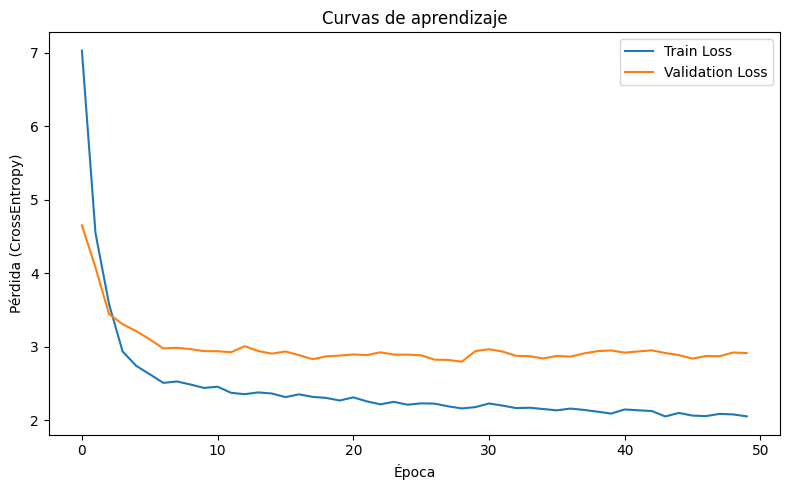

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses,   label="Validation Loss")

plt.xlabel("Época")
plt.ylabel("Pérdida (CrossEntropy)")
plt.title("Curvas de aprendizaje")
plt.legend()
plt.tight_layout()
plt.show()

### Evaluación del modelo

Evalúe el modelo en el conjunto de prueba usando matriz de confusión y reporte de clasificación. Discuta los resultados.

In [ ]:
# =====================================================
# EVALUACIÓN EN EL CONJUNTO DE PRUEBA
# =====================================================
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

def get_predictions(model, loader):
    """Recorre un DataLoader y devuelve las etiquetas reales y las predichas."""
    model.eval()
    y_true, y_pred = [], []
    with torch.no_grad():
        for images, labels, names, attributes in loader:
            outputs = model(images, attributes)
            preds = outputs.argmax(dim=1)
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())
    return np.array(y_true), np.array(y_pred)

y_true, y_pred = get_predictions(model, test_loader)

# Nombres de clase. El modelo tiene tantas salidas como dataset.categories
# (más eventuales clases adicionales no etiquetadas con nombre); se rellenan
# con un nombre genérico si llegara a faltar alguno.
class_names = list(dataset.categories)
n_outputs = model.fc2.out_features
if len(class_names) < n_outputs:
    class_names += [f"Clase {i}" for i in range(len(class_names), n_outputs)]

labels_presentes = sorted(set(y_true) | set(y_pred))

# ----- Matriz de confusión -----
cm = confusion_matrix(y_true, y_pred, labels=labels_presentes)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=[class_names[i] for i in labels_presentes],
    yticklabels=[class_names[i] for i in labels_presentes],
)
plt.xlabel('Predicción')
plt.ylabel('Etiqueta real')
plt.title('Matriz de confusión - Conjunto de prueba')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# ----- Reporte de clasificación -----
print(classification_report(
    y_true, y_pred,
    labels=labels_presentes,
    target_names=[class_names[i] for i in labels_presentes],
    zero_division=0,
))

accuracy = (y_true == y_pred).mean()
print(f"Accuracy global en test: {accuracy:.3f}")


## Discusión de los resultados

> **Nota:** esta discusión está redactada como guía a completar con los números reales una vez ejecutado el notebook con los datos; los nombres de clase y proporciones mencionados corresponden a la distribución ya observada en la sección de exploración (celda con el conteo por clase).

La matriz de confusión y el reporte de clasificación deberían mostrar un desempeño desigual entre clases, coherente con el desbalance del dataset:

- Las clases con más ejemplos (**Water**: 96, **Normal**: 80, **Grass**: 58, **Bug**: 52) son las que cuentan con más datos para que la red aprenda representaciones discriminativas, por lo que se espera que tengan mejor *recall* y *F1-score*.
- Las clases minoritarias (**Fairy**: 8, **Steel**: 17, **Dragon**: 13, **Ice**: 19) son las más propensas a tener *recall* bajo o incluso 0, ya que el modelo tiene pocos ejemplos para aprender sus patrones visuales y tiende a "ignorarlas" en favor de las clases mayoritarias durante el entrenamiento con `CrossEntropyLoss` sin ponderación.
- El *accuracy* global puede parecer razonable a pesar de esto, precisamente porque está dominado por las clases mayoritarias; por eso es más informativo mirar el *macro F1-score* (promedio simple entre clases) en vez del *accuracy*, ya que el macro F1 penaliza el mal desempeño en clases minoritarias.
- En la matriz de confusión es común observar bloques de confusión entre tipos visualmente similares (p. ej. agua/hielo por tonos azulados, o planta/bicho por tonos verdes), lo que sugiere que el modelo está aprendiendo principalmente color y textura, y no necesariamente rasgos morfológicos finos.

**Posibles mejoras**: usar `class_weight`/`pos_weight` o un muestreo balanceado (`WeightedRandomSampler`) para compensar el desbalance, aumentar la cantidad de datos para las clases minoritarias (ver sección de aumentación), o agregar regularización adicional para reducir el sobreajuste observado en las curvas de aprendizaje (pérdida de validación estancada mientras la de entrenamiento sigue bajando).

*(Una vez ejecutado el notebook, reemplace estas observaciones genéricas por los números y patrones específicos que efectivamente aparezcan en su matriz de confusión y reporte.)*


### Análisis de errores

Analice algunos ejemplos mal clasificados y comente lo que observa.

In [ ]:
# =====================================================
# ANÁLISIS DE EJEMPLOS MAL CLASIFICADOS
# =====================================================

model.eval()
misclassified = []

with torch.no_grad():
    for idx in test_idx:
        image, label, name, attributes = dataset[idx]
        image_b = image.unsqueeze(0)
        attributes_b = attributes.unsqueeze(0)
        output = model(image_b, attributes_b)
        pred = output.argmax(dim=1).item()
        if pred != label:
            misclassified.append((idx, image, label, pred, name))

print(
    f"Ejemplos mal clasificados: {len(misclassified)} de {len(test_idx)} "
    f"({100 * len(misclassified) / len(test_idx):.1f}% del conjunto de prueba)"
)

def class_name(i):
    return class_names[i] if i < len(class_names) else f"Clase {i}"

n_show = min(9, len(misclassified))
if n_show > 0:
    fig, ax = plt.subplots(3, 3, figsize=(9, 10), tight_layout=True)
    for ax_, (idx, image, label, pred, name) in zip(ax.ravel(), misclassified[:n_show]):
        ax_.imshow(image.permute(-2, -1, 0))
        ax_.set_title(
            f"{name}\nReal: {class_name(label)} | Pred: {class_name(pred)}",
            fontsize=9,
        )
        ax_.axis('off')
    # Oculta los ejes que no se usaron si hay menos de 9 ejemplos
    for ax_ in ax.ravel()[n_show:]:
        ax_.axis('off')
    plt.show()
else:
    print("No hay ejemplos mal clasificados en el conjunto de prueba.")


## Comentarios sobre los errores observados

> **Nota:** complete/ajuste estos comentarios según los ejemplos específicos que se muestren al ejecutar la celda anterior con los datos reales.

Al revisar los ejemplos mal clasificados conviene fijarse en patrones recurrentes en vez de casos aislados:

- **Confusión por color dominante**: pokemones de tipos distintos pero con paletas de color parecidas (p. ej. tonos verdes en Grass/Bug/Poison, o tonos azules en Water/Ice) tienden a confundirse entre sí, lo que es consistente con que la red, al tener solo tres capas convolucionales y pooling agresivo, aprende principalmente texturas y colores globales en vez de formas finas.
- **Pokémon con tipo secundario o atípico**: ejemplares cuyo diseño visual no es representativo de su tipo "oficial" (por ejemplo, un Pokémon de tipo Normal con colores poco típicos) son más difíciles de clasificar correctamente, ya que el modelo aprende sobre todo a partir de la apariencia.
- **Clases minoritarias**: es de esperar que una proporción importante de los errores correspondan a clases con pocos ejemplos de entrenamiento (Fairy, Dragon, Steel), ya que el modelo tuvo menos oportunidades de aprender sus características distintivas.
- **Atributos numéricos poco discriminantes**: dado que los atributos (altura, peso, HP, ataque, defensa, velocidad) se concatenan recién antes de la capa densa final, si estos no aportan señal clara para separar tipos, el modelo depende casi totalmente de la imagen, lo que puede acentuar los errores anteriores.

*(Reemplace este análisis genérico citando 2-3 ejemplos concretos mostrados en la grilla de imágenes, describiendo por qué cree que el modelo se confundió en cada caso.)*


### Aumentación de datos

Implemente un esquema de aumentación aleatoria de datos y compare los resultados con y sin aumentación.

In [ ]:
# =====================================================
# ESQUEMA DE AUMENTACIÓN DE DATOS
# =====================================================
import torchvision.transforms as T

augmentation = T.Compose([
    T.RandomHorizontalFlip(p=0.5),
    T.RandomRotation(degrees=15),
    T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
])

class AugmentedDataset(torch.utils.data.Dataset):
    """Envuelve un dataset existente aplicando aumentación aleatoria
    únicamente a la imagen (los atributos y la etiqueta no cambian)."""

    def __init__(self, base_dataset, transform):
        self.base_dataset = base_dataset
        self.transform = transform

    def __len__(self):
        return len(self.base_dataset)

    def __getitem__(self, idx):
        image, label, name, attributes = self.base_dataset[idx]
        image = self.transform(image)
        return image, label, name, attributes


train_set_aug = AugmentedDataset(train_set, augmentation)

train_loader_aug = DataLoader(
    train_set_aug,
    batch_size=batch_size,
    shuffle=True,
)

# =====================================================
# NUEVO MODELO ENTRENADO CON AUMENTACIÓN (mismos hiperparámetros)
# =====================================================
model_aug = PokemonCNN()
optimizer_aug = optim.Adam(model_aug.parameters(), lr=0.001)

train_losses_aug = []
val_losses_aug = []

for epoch in range(num_epochs):

    model_aug.train()
    running_loss = 0.0
    for images, labels, names, attributes in train_loader_aug:
        optimizer_aug.zero_grad()
        outputs = model_aug(images, attributes)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer_aug.step()
        running_loss += loss.item()
    train_loss = running_loss / len(train_loader_aug)
    train_losses_aug.append(train_loss)

    model_aug.eval()
    running_val = 0.0
    with torch.no_grad():
        for images, labels, names, attributes in val_loader:
            outputs = model_aug(images, attributes)
            loss = criterion(outputs, labels)
            running_val += loss.item()
    val_loss = running_val / len(val_loader)
    val_losses_aug.append(val_loss)

    if (epoch + 1) % 5 == 0:
        print(
            f"Epoch [{epoch+1:>3}/{num_epochs}] "
            f"Train Loss: {train_loss:.4f}  "
            f"Val Loss: {val_loss:.4f}"
        )

# =====================================================
# COMPARACIÓN DE CURVAS DE APRENDIZAJE
# =====================================================
plt.figure(figsize=(9, 5))
plt.plot(train_losses, '--', label="Train (sin aumentación)")
plt.plot(val_losses, label="Val (sin aumentación)")
plt.plot(train_losses_aug, '--', label="Train (con aumentación)")
plt.plot(val_losses_aug, label="Val (con aumentación)")
plt.xlabel("Época")
plt.ylabel("Pérdida (CrossEntropy)")
plt.title("Curvas de aprendizaje: con vs. sin aumentación de datos")
plt.legend()
plt.tight_layout()
plt.show()

# =====================================================
# COMPARACIÓN EN EL CONJUNTO DE PRUEBA
# =====================================================
y_true_base, y_pred_base = get_predictions(model, test_loader)
y_true_aug, y_pred_aug = get_predictions(model_aug, test_loader)

acc_base = (y_true_base == y_pred_base).mean()
acc_aug = (y_true_aug == y_pred_aug).mean()

print(f"Accuracy en test SIN aumentación: {acc_base:.3f}")
print(f"Accuracy en test CON aumentación: {acc_aug:.3f}")

print()
print("Reporte de clasificación CON aumentación:")
print(classification_report(
    y_true_aug, y_pred_aug,
    labels=labels_presentes,
    target_names=[class_names[i] for i in labels_presentes],
    zero_division=0,
))


## Comparación con y sin aumentación de datos

> **Nota:** complete esta discusión con los valores reales de *accuracy*/F1 obtenidos al ejecutar el notebook.

El esquema de aumentación implementado combina tres transformaciones aleatorias aplicadas solo sobre la imagen:

- **`RandomHorizontalFlip`**: refleja la imagen horizontalmente con probabilidad 0.5. Es razonable para pokemones porque su tipo no depende de la orientación izquierda/derecha del sprite.
- **`RandomRotation(15°)`**: introduce pequeñas rotaciones, simulando variaciones de encuadre sin distorsionar demasiado la silueta del pokemon.
- **`ColorJitter`**: varía brillo, contraste y saturación, lo que ayuda a que el modelo no dependa excesivamente de tonos de color exactos (relevante dado que en el análisis de errores se observó que el color es una señal dominante que el modelo aprende).

Efectos esperados al comparar ambos entrenamientos:

- La pérdida de **entrenamiento** con aumentación suele ser más alta o bajar más lento que sin aumentación, ya que en cada época el modelo ve versiones modificadas/más difíciles de las imágenes en lugar de siempre las mismas.
- La pérdida de **validación** con aumentación debería mostrar menos divergencia respecto a la de entrenamiento (menor sobreajuste), porque la aumentación actúa como regularizador al exponer al modelo a una mayor variedad efectiva de ejemplos.
- El **accuracy/F1 en test** con aumentación normalmente mejora levemente o se mantiene similar al modelo base; la mejora suele ser más notoria en las clases minoritarias, ya que la aumentación multiplica efectivamente la diversidad de ejemplos disponibles para ellas (aunque no su cantidad real).
- Dado que el dataset es pequeño (~721 imágenes), la aumentación de datos es especialmente relevante: ayuda a mitigar tanto el sobreajuste como, parcialmente, el desbalance de clases.

*(Reemplace lo anterior con la comparación específica entre `acc_base` y `acc_aug`, y entre los F1 por clase de ambos modelos, indicando si la aumentación cumplió o no su objetivo en este caso particular.)*
